In [1]:
import pandas as pd

routes = pd.read_csv("../data/raw/google_transit/routes.txt")
routes.head()

,agency_id,route_id,route_short_name,route_long_name,route_type,route_rul,route_color,route_text_color
0,50066,1,1,Bronzeville/Union Station,3,http://www.transitchicago.com/bus/1/,99999C,ffffff
1,50066,2,2,Hyde Park Express,3,http://www.transitchicago.com/bus/2/,b71234,ffffff
2,50066,3,3,King Drive,3,http://www.transitchicago.com/bus/3/,99999C,ffffff
3,50066,4,4,Cottage Grove,3,http://www.transitchicago.com/bus/4/,414145,ffffff
4,50066,X4,X4,Cottage Grove Express,3,http://www.transitchicago.com/bus/X4/,b71234,ffffff


In [2]:
routes = routes[routes["route_type"] == 3]
routes["route_id"].unique()[:20]

array(['1', '2', '3', '4', 'X4', 'N5', '6', '7', '8', '8A', '9', 'X9',
       '11', '12', 'J14', '15', '18', '20', '21', '22'], dtype=object)

In [3]:
trips = pd.read_csv("../data/raw/google_transit/trips.txt")
trips.head()

,route_id,service_id,trip_id,direction_id,block_id,shape_id,direction,wheelchair_accessible,schd_trip_id
0,1,67701,6770004362020,0,677000002398,67706351,South,1,4362020
1,1,67701,6770007836020,0,677000002391,67706351,South,1,7836020
2,1,67701,6770008651020,0,677000002401,67706351,South,1,8651020
3,1,67701,6770009884020,0,677000002392,67706351,South,1,9884020
4,1,67701,6770010610020,0,677000002391,67706351,South,1,10610020


In [4]:
trips[["route_id", "shape_id"]].head()

,route_id,shape_id
0,1,67706351
1,1,67706351
2,1,67706351
3,1,67706351
4,1,67706351


In [5]:
trips["route_id"].unique()[:20]

array(['1', '100', '103', '106', '108', '11', '111', '111A', '112', '115',
       '119', '12', '120', '121', '124', '125', '126', '134', '135',
       '136'], dtype=object)

In [6]:
# Keep only bus trips
trips = trips[trips["route_id"].isin(routes["route_id"])]

print("Number of bus trips:", len(trips))
trips.head()

Number of bus trips: 44878


,route_id,service_id,trip_id,direction_id,block_id,shape_id,direction,wheelchair_accessible,schd_trip_id
0,1,67701,6770004362020,0,677000002398,67706351,South,1,4362020
1,1,67701,6770007836020,0,677000002391,67706351,South,1,7836020
2,1,67701,6770008651020,0,677000002401,67706351,South,1,8651020
3,1,67701,6770009884020,0,677000002392,67706351,South,1,9884020
4,1,67701,6770010610020,0,677000002391,67706351,South,1,10610020


In [7]:
shapes = pd.read_csv("../data/raw/google_transit/shapes.txt")
shapes.head()

,shape_id,shape_pt_lat,shape_pt_lon,shape_pt_sequence,shape_dist_traveled
0,67700095,41.911304,-87.631222,1,0
1,67700095,41.911304,-87.631222,2,49
2,67700095,41.911180,-87.631290,3,106
3,67700095,41.911180,-87.631500,4,158
4,67700095,41.911180,-87.631690,5,225


In [8]:
shapes[["shape_id", "shape_pt_lat", "shape_pt_lon"]].head()

,shape_id,shape_pt_lat,shape_pt_lon
0,67700095,41.911304,-87.631222
1,67700095,41.911304,-87.631222
2,67700095,41.911180,-87.631290
3,67700095,41.911180,-87.631500
4,67700095,41.911180,-87.631690


In [9]:
# Get one shape per route
route_shapes = trips.groupby("route_id")["shape_id"].first().reset_index()

route_shapes.head()

,route_id,shape_id
0,1,67706351
1,100,67700701
2,103,67700711
3,106,67704491
4,108,67703411


In [10]:
# Merge route_shapes with shapes
route_geo = route_shapes.merge(shapes, on="shape_id")

route_geo.head()

,route_id,shape_id,shape_pt_lat,shape_pt_lon,shape_pt_sequence,shape_dist_traveled
0,1,67706351,41.87450,-87.644386,1,0
1,1,67706351,41.87450,-87.644386,2,18
2,1,67706351,41.87450,-87.644320,3,33
3,1,67706351,41.87446,-87.644310,4,70
4,1,67706351,41.87436,-87.644320,5,116


In [11]:
# Compute centroid for each route
route_centroids = route_geo.groupby("route_id").agg({
    "shape_pt_lat": "mean",
    "shape_pt_lon": "mean"
}).reset_index()

route_centroids.rename(columns={
    "shape_pt_lat": "centroid_lat",
    "shape_pt_lon": "centroid_lon"
}, inplace=True)

route_centroids.head()

,route_id,centroid_lat,centroid_lon
0,1,41.862708,-87.627518
1,100,41.712373,-87.566462
2,103,41.708733,-87.660233
3,106,41.710615,-87.608401
4,108,41.683581,-87.642054


In [12]:
# Compute centroid for each route
route_centroids = route_geo.groupby("route_id").agg({
    "shape_pt_lat": "mean",
    "shape_pt_lon": "mean"
}).reset_index()

route_centroids.rename(columns={
    "shape_pt_lat": "centroid_lat",
    "shape_pt_lon": "centroid_lon"
}, inplace=True)

route_centroids.head()

,route_id,centroid_lat,centroid_lon
0,1,41.862708,-87.627518
1,100,41.712373,-87.566462
2,103,41.708733,-87.660233
3,106,41.710615,-87.608401
4,108,41.683581,-87.642054


In [13]:
!python -m pip install scikit-learn

You should consider upgrading via the 'c:\Users\Aasiya\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [14]:
from sklearn.cluster import KMeans

# Select coordinates
X = route_centroids[["centroid_lat", "centroid_lon"]]

# Apply KMeans
kmeans = KMeans(n_clusters=8, random_state=42)
route_centroids["client_id"] = kmeans.fit_predict(X)

route_centroids.head()

,route_id,centroid_lat,centroid_lon,client_id
0,1,41.862708,-87.627518,4
1,100,41.712373,-87.566462,2
2,103,41.708733,-87.660233,2
3,106,41.710615,-87.608401,2
4,108,41.683581,-87.642054,2


In [15]:
ridership = pd.read_csv("../data/raw/CTA_Ridership_Bus_Routes_Monthly_Day-Type_Averages_&_Totals.csv")
ridership.head()

,route,routename,Month_Beginning,Avg_Weekday_Rides,Avg_Saturday_Rides,Avg_Sunday-Holiday_Rides,MonthTotal
0,1,Indiana/Hyde Park,01/01/2001,"6,982.6",0,0,"153,617"
1,2,Hyde Park Express,01/01/2001,"1,000",0,0,"22,001"
2,3,King Drive,01/01/2001,"21,406.5","13,210.7","8,725.3","567,413"
3,4,Cottage Grove,01/01/2001,"22,432.2","17,994","10,662.2","618,796"
4,6,Jackson Park Express,01/01/2001,"18,443","13,088.2","7,165.6","493,926"


In [16]:
# Remove commas and convert to numeric
cols_to_clean = [
    "Avg_Weekday_Rides",
    "Avg_Saturday_Rides",
    "Avg_Sunday-Holiday_Rides",
    "MonthTotal"
]

for col in cols_to_clean:
    ridership[col] = ridership[col].astype(str).str.replace(",", "")
    ridership[col] = pd.to_numeric(ridership[col], errors="coerce")

ridership.head()

,route,routename,Month_Beginning,Avg_Weekday_Rides,Avg_Saturday_Rides,Avg_Sunday-Holiday_Rides,MonthTotal
0,1,Indiana/Hyde Park,01/01/2001,6982.6,0.0,0.0,153617
1,2,Hyde Park Express,01/01/2001,1000.0,0.0,0.0,22001
2,3,King Drive,01/01/2001,21406.5,13210.7,8725.3,567413
3,4,Cottage Grove,01/01/2001,22432.2,17994.0,10662.2,618796
4,6,Jackson Park Express,01/01/2001,18443.0,13088.2,7165.6,493926


In [17]:
ridership.rename(columns={"route": "route_id"}, inplace=True)

In [18]:
ridership["Month_Beginning"] = pd.to_datetime(ridership["Month_Beginning"])

In [19]:
merged_data = ridership.merge(route_centroids, on="route_id")

merged_data.head()

,route_id,routename,Month_Beginning,Avg_Weekday_Rides,Avg_Saturday_Rides,Avg_Sunday-Holiday_Rides,MonthTotal,centroid_lat,centroid_lon,client_id
0,1,Indiana/Hyde Park,2001-01-01,6982.6,0.0,0.0,153617,41.862708,-87.627518,4
1,2,Hyde Park Express,2001-01-01,1000.0,0.0,0.0,22001,41.837974,-87.606034,0
2,3,King Drive,2001-01-01,21406.5,13210.7,8725.3,567413,41.812072,-87.619009,0
3,4,Cottage Grove,2001-01-01,22432.2,17994.0,10662.2,618796,41.793461,-87.611742,0
4,6,Jackson Park Express,2001-01-01,18443.0,13088.2,7165.6,493926,41.815212,-87.593446,0


In [20]:
merged_data["client_id"].value_counts()

client_id
5    5478
1    5382
4    5194
6    5054
0    4132
2    4007
7    3289
3    2248
Name: count, dtype: int64

In [21]:
client_datasets = {}

for cid in merged_data["client_id"].unique():
    client_datasets[cid] = merged_data[merged_data["client_id"] == cid]

print("Number of clients:", len(client_datasets))

Number of clients: 8


In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

client_models = {}
client_metrics = {}

for cid, data in client_datasets.items():
    
    X = data[[
        "Avg_Weekday_Rides",
        "Avg_Saturday_Rides",
        "Avg_Sunday-Holiday_Rides"
    ]]
    
    y = data["MonthTotal"]
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    predictions = model.predict(X_test)
    mse = mean_squared_error(y_test, predictions)
    
    client_models[cid] = model
    client_metrics[cid] = mse

client_metrics

{np.int32(4): 40391335.18917528,
 np.int32(0): 63323943.10703177,
 np.int32(5): 106022363.01992798,
 np.int32(2): 20163338.08481339,
 np.int32(6): 11881266.679560583,
 np.int32(7): 80987149.68512794,
 np.int32(3): 8649324.042448394,
 np.int32(1): 70254449.74451537}

In [23]:
import numpy as np

# Collect all coefficients
coefs = []
intercepts = []

for model in client_models.values():
    coefs.append(model.coef_)
    intercepts.append(model.intercept_)

# Convert to arrays
coefs = np.array(coefs)
intercepts = np.array(intercepts)

# FedAvg
global_coef = np.mean(coefs, axis=0)
global_intercept = np.mean(intercepts)

global_coef, global_intercept

(array([21.0219824 ,  3.83694291,  5.98690954]), np.float64(319.8286501550747))

In [24]:
global_model = LinearRegression()
global_model.coef_ = global_coef
global_model.intercept_ = global_intercept

In [25]:
X_all = merged_data[[
    "Avg_Weekday_Rides",
    "Avg_Saturday_Rides",
    "Avg_Sunday-Holiday_Rides"
]]

y_all = merged_data["MonthTotal"]

preds = global_model.predict(X_all)

global_mse = mean_squared_error(y_all, preds)

global_mse

c:\Users\Aasiya\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


57542536.69412212

In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Train on full dataset
central_model = LinearRegression()
central_model.fit(X_all, y_all)

# Predict
central_preds = central_model.predict(X_all)

# Evaluate
central_mse = mean_squared_error(y_all, central_preds)

central_mse

57478148.475219764

In [27]:
merged_data.to_csv("../data/processed/final_merged_clients.csv", index=False)

In [28]:
import sys
import os

# Get project root
project_root = os.path.abspath("..")
sys.path.append(project_root)

from backend.data_manager import DataManager
from backend.client_manager import ClientManager
from backend.federated_trainer import FederatedTrainer
from backend.evaluator import Evaluator

# Load data
dm = DataManager("../data/processed/final_merged_clients.csv")
df = dm.load_data()

# Initialize clients
cm = ClientManager(df)
cm.initialize_clients()

# -------------------------
# Baseline Training
# -------------------------

trainer = FederatedTrainer(cm)
global_model = trainer.train()

eval = Evaluator(global_model, cm)

print("Baseline MSE:", eval.evaluate_global())
print("Per Client MSE:", eval.evaluate_per_client())

# -------------------------
# Onboard New Depot
# -------------------------

new_id = cm.onboard_new_depot(
    source_client_id=2,
    route_fraction=0.3,
    months_limit=24
)

trainer = FederatedTrainer(cm)
global_model = trainer.train()

eval = Evaluator(global_model, cm)

print("\nAfter Onboarding MSE:", eval.evaluate_global())
print("Per Client MSE:", eval.evaluate_per_client())

# -------------------------
# Deactivate Depot
# -------------------------

cm.deactivate_depot(new_id)

trainer = FederatedTrainer(cm)
global_model = trainer.train()

eval = Evaluator(global_model, cm)

print("\nAfter Deactivation MSE:", eval.evaluate_global())
print("Per Client MSE:", eval.evaluate_per_client())

ModuleNotFoundError: No module named 'data_manager'

In [ ]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\Aasiya\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


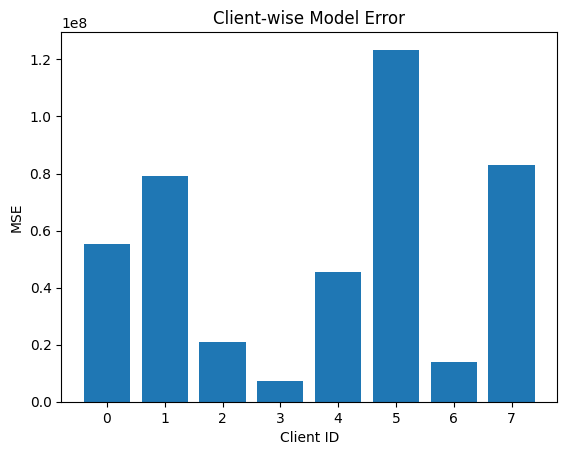

In [ ]:
import matplotlib.pyplot as plt

client_mse = eval.evaluate_per_client()

plt.bar(client_mse.keys(), client_mse.values())
plt.xlabel("Client ID")
plt.ylabel("MSE")
plt.title("Client-wise Model Error")
plt.show()

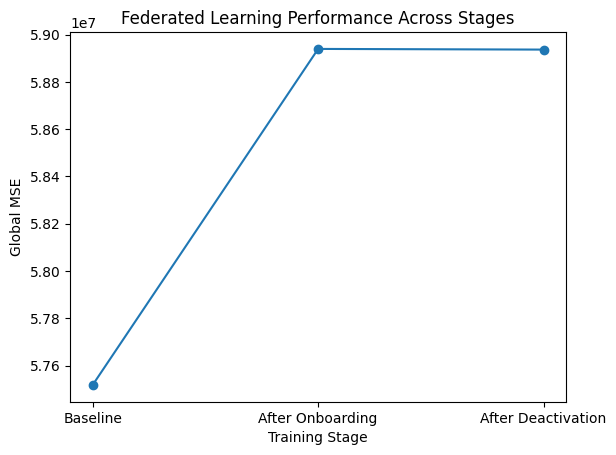

In [ ]:
import matplotlib.pyplot as plt

labels = ["Baseline", "After Onboarding", "After Deactivation"]
values = [57517944, 58939870, 58937024]

plt.plot(labels, values, marker='o')
plt.xlabel("Training Stage")
plt.ylabel("Global MSE")
plt.title("Federated Learning Performance Across Stages")
plt.show()

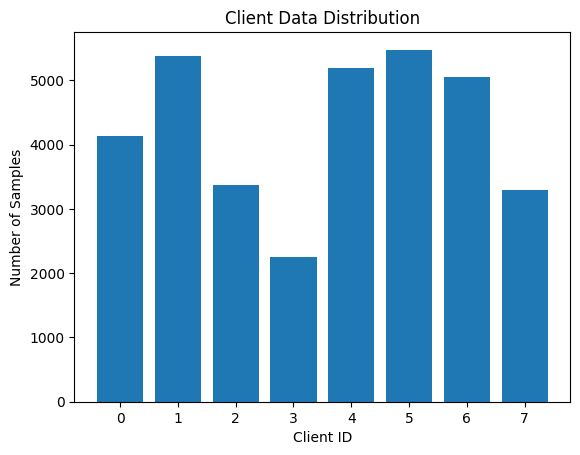

In [ ]:
import matplotlib.pyplot as plt

client_sizes = {cid: len(data) for cid, data in cm.active_clients.items()}

plt.bar(client_sizes.keys(), client_sizes.values())
plt.xlabel("Client ID")
plt.ylabel("Number of Samples")
plt.title("Client Data Distribution")
plt.show()